In [ ]:
import pickle
import scipy.signal
from scipy import signal
import h5py
import numpy as np

In [ ]:
import mne
import numpy as np
import h5py

def load_ssvep_data(file_path):
    """
    Load EEG-Data and Trigger from .mat v7.3 (HDF5)
    
    As I tried it with loadmat from scipy.io I had the following error
    "NotImplementedError: Please use HDF reader for matlab v7.3 files, e.g. h5py"
    Thats why I use h5py
    """
    with h5py.File(file_path, "r") as f:
       # print(list(f.keys())) # check keys name - its "y" thats why I use y below
       # print(f["y"].shape)
        raw_data = f["y"][:]    # get the real np.ndarray from the data          
        eegs     = raw_data[:, 1:9]       # CH2 bis CH9 → EEG
        triggers = raw_data[:, 9]         # CH10 → Trigger (LED on/off)

    return eegs, triggers

# 1. Daten laden
eeg_data, trigger_data = load_ssvep_data("ssvep/subject_2_fvep_led_training_2.mat")

# 2. MNE Raw-Objekt erstellen
sfreq = 256  
ch_names = ["PO7", "PO3", "POz", "PO4", "PO8", "O1", "Oz", "O2", "Trigger"]
ch_types = ['eeg'] * 8 + ['stim']
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
raw = mne.io.RawArray(np.vstack([eeg_data.T, trigger_data]), info)


# Montage:
# I suppose the name from https://mne.tools/stable/auto_tutorials/intro/40_sensor_locations.html
raw.set_montage("standard_1020")

Creating RawArray with float64 data, n_channels=9, n_times=57697
    Range : 0 ... 57696 =      0.000 ...   225.375 secs
Ready.


<RawArray | 9 x 57697 (225.4 s), ~4.0 MiB, data loaded>

Fitting ICA to data using 8 channels (please be patient, this may take a while)
Selecting by number: 5 components
Fitting ICA took 0.0s.


/var/folders/b_/13ns3vn128sfcpkm5ql4glyw0000gn/T/ipykernel_24340/3456637961.py:2: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw, picks='eeg')  # just EEG-Channels (CH2-CH9) for ICA


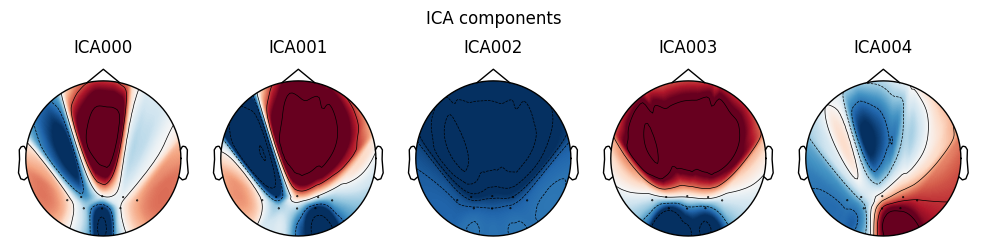

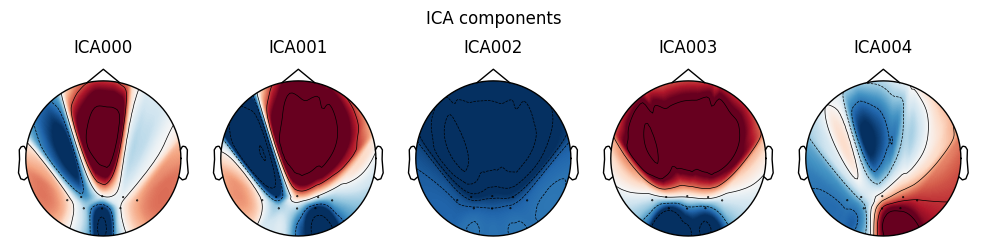

In [43]:
ica = mne.preprocessing.ICA(n_components=5, random_state=97)
ica.fit(raw, picks='eeg')  # just EEG-Channels (CH2-CH9) for ICA
ica.plot_components()

Creating RawArray with float64 data, n_channels=5, n_times=57697


    Range : 0 ... 57696 =      0.000 ...   225.375 secs
Ready.
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/var/folders/b_/13ns3vn128sfcpkm5ql4glyw0000gn/T/ipykernel_24340/1892316288.py:9: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd.plot(picks='ICA000')
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


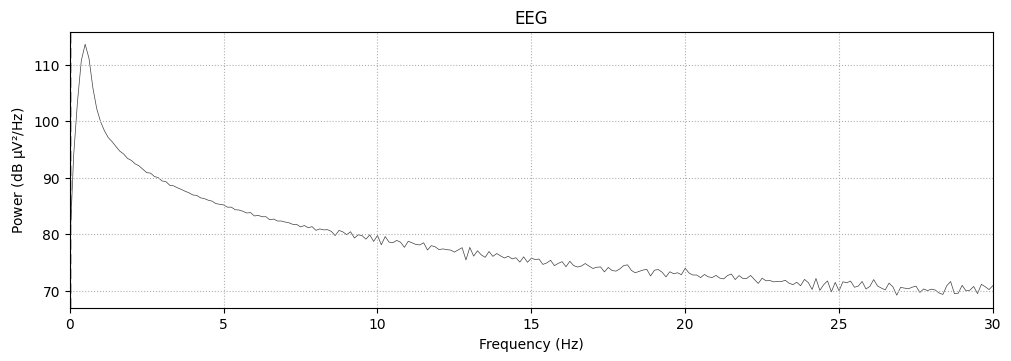

In [37]:
ica_sources = ica.get_sources(raw).get_data()
info = mne.create_info(ch_names=ica.get_sources(raw).ch_names,
                       sfreq=raw.info['sfreq'],
                       ch_types='eeg')

ica_raw = mne.io.RawArray(ica_sources, info)

psd = ica_raw.compute_psd(fmax=30)
psd.plot(picks='ICA000') 

In [38]:
ica.exclude = [0, 1, 3]
raw_clean = raw.copy()
ica.apply(raw_clean)        # no ICA000 and ICA001 
raw_clean.filter(7., 35., fir_design='firwin')

Applying ICA to Raw instance
    Transforming to ICA space (5 components)
    Zeroing out 3 ICA components
    Projecting back using 8 PCA components
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 423 samples (1.652 s)



<RawArray | 9 x 57697 (225.4 s), ~4.0 MiB, data loaded>

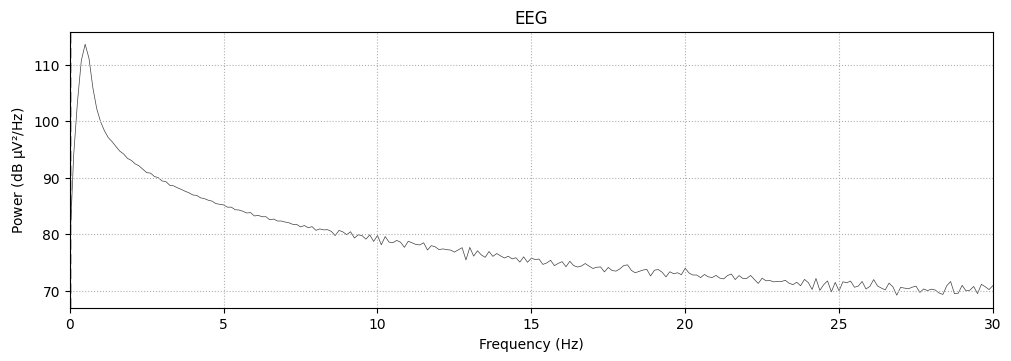

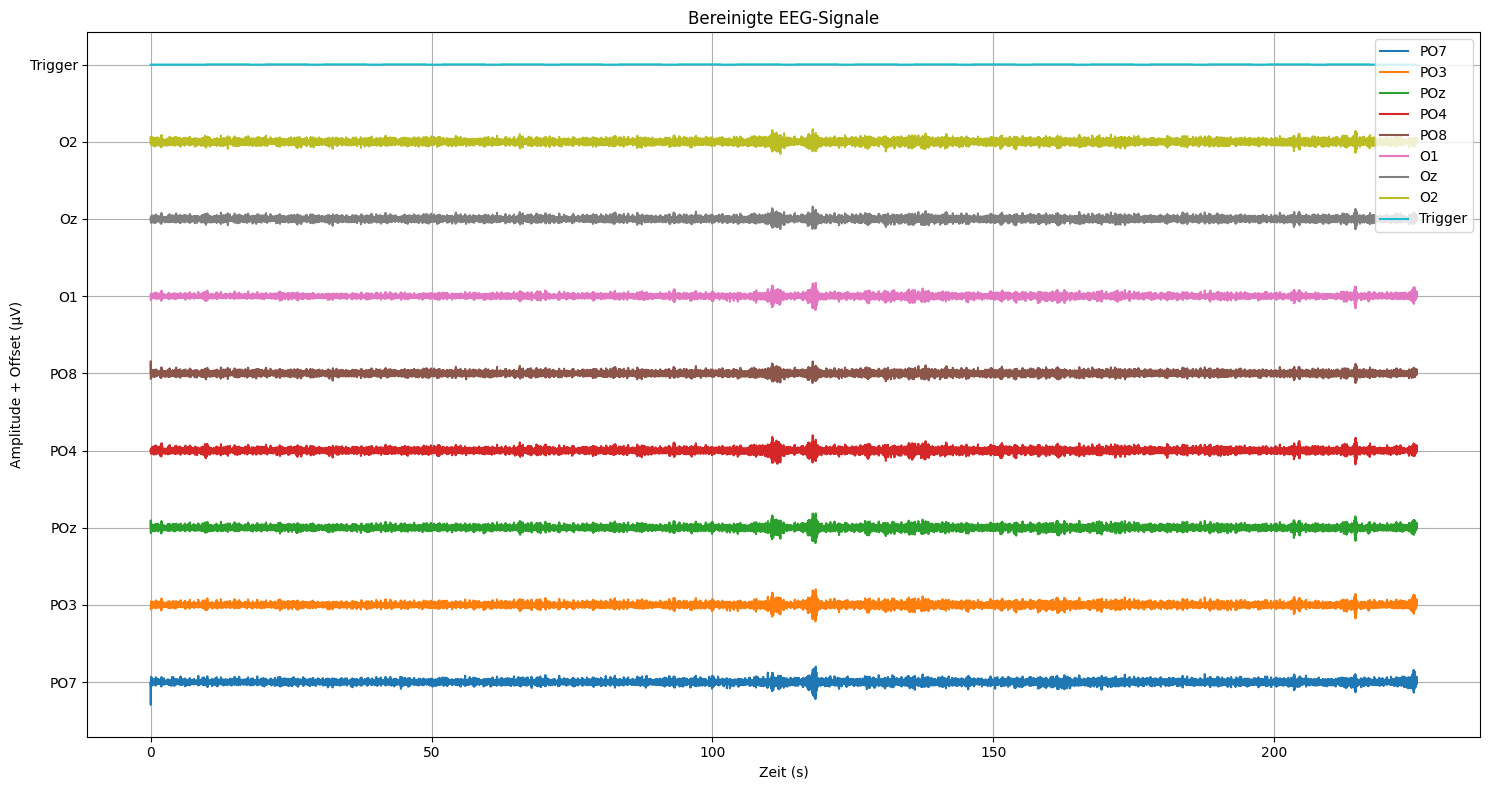

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


data, times = raw_clean.get_data(return_times=True)  # raw_clean = ICA-bereinigte Daten
ch_names = raw_clean.ch_names
sfreq = raw_clean.info['sfreq'] 

start_sec = 0
duration_sec = 250
start_sample = int(start_sec * sfreq)
end_sample = int((start_sec + duration_sec) * sfreq)

data = data[:, start_sample:end_sample]
times = times[start_sample:end_sample]

# Plotten
plt.figure(figsize=(15, 8))
offset = 300  # disctance between channnels
colors = plt.cm.tab10(np.linspace(0, 1, len(data)))  # colors

for i, (ch_data, name) in enumerate(zip(data, ch_names)):
    plt.plot(times, ch_data + i * offset, color=colors[i], label=name)

plt.xlabel("Zeit (s)")
plt.ylabel("Amplitude + Offset (µV)")
plt.title("Bereinigte EEG-Signale")
plt.yticks([i * offset for i in range(len(ch_names))], ch_names)
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


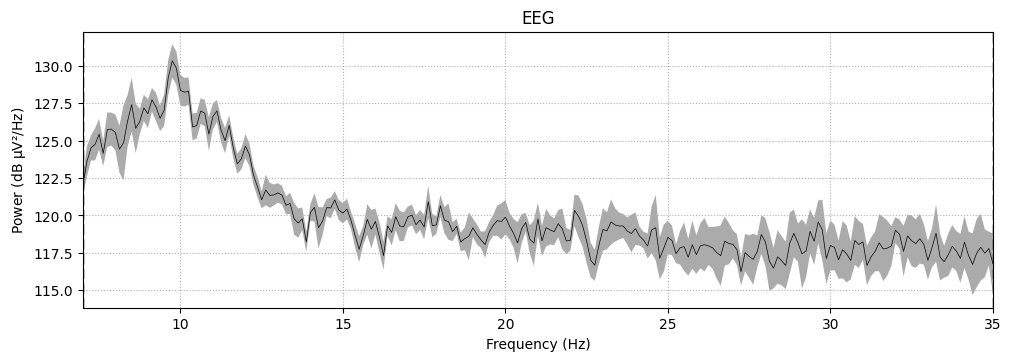

In [40]:
raw_clean.plot_psd(fmax=30)
raw_clean.plot_psd(
    fmin=7,        
    fmax=35,      
    average=True,  
    picks='eeg',  
    dB=True         # log
)

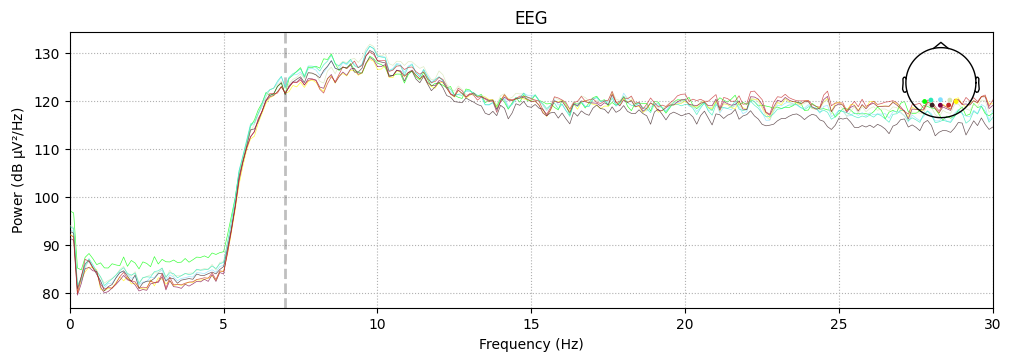

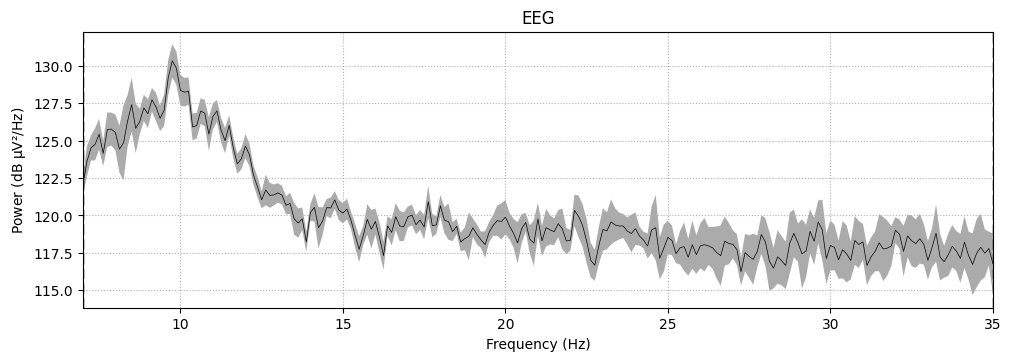

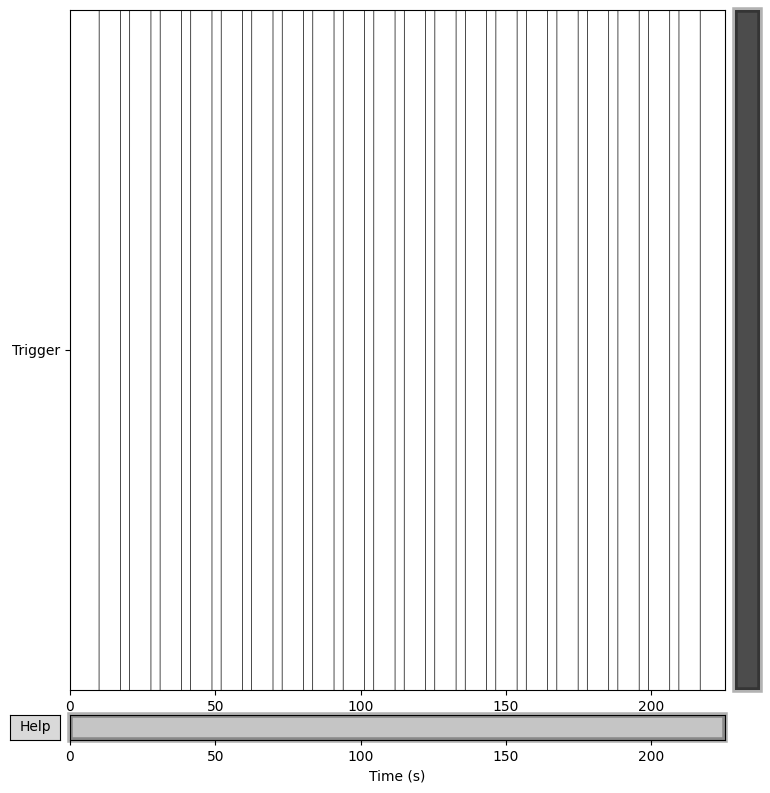

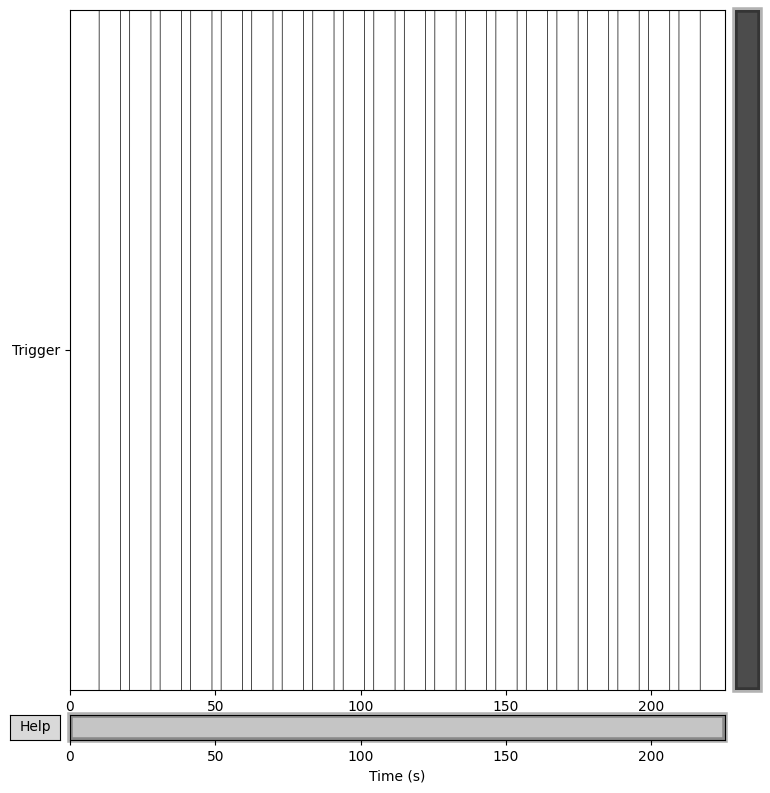

In [41]:
raw_clean.plot(picks="stim", duration=raw_clean.times[-1], n_channels=1, scalings='auto')

In [42]:
raw.save("subject2_clean_training_2.fif", overwrite=True)

Writing /Users/dascha/Desktop/hackathon/subject2_clean_training_2.fif
Closing /Users/dascha/Desktop/hackathon/subject2_clean_training_2.fif
[done]


/var/folders/b_/13ns3vn128sfcpkm5ql4glyw0000gn/T/ipykernel_24340/595720886.py:1: RuntimeWarning: This filename (/Users/dascha/Desktop/hackathon/subject2_clean_training_2.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save("subject2_clean_training_2.fif", overwrite=True)


[PosixPath('/Users/dascha/Desktop/hackathon/subject2_clean_training_2.fif')]